# Real-data experiment 3: Swiss phenological phases on a torus

This notebook reproduces the periodic example from *One Moran, Three
Geary Measures*. Each station is represented by its intrinsic mean
peak-bloom phase before 1990 and from 1990 onward, giving an observation
on $S^1 \times S^1$. Stations must have at least eight observations in
each era.

`PAPER_SCALE=True` reproduces the manuscript's 999 global and 499 local
permutations; set it to `False` for 499 global permutations.

**Source: MeteoSwiss.**

In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "autocorr.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import autocorr as ac

ac.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = True
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")

Public root located. PAPER_SCALE=True


In [2]:
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Patch
from pyproj import Transformer

SEED = 20260719
global_permutations = 999 if PAPER_SCALE else 499
local_permutations = 499
stations = ac.build_swiss_phases()
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
x, y = transformer.transform(stations["lon"].to_numpy(), stations["lat"].to_numpy())
spatial_coordinates = np.column_stack([x, y])
W = ac.sym_knn(spatial_coordinates, k=4)
phases = stations[["theta_early", "theta_recent"]].to_numpy(float)
mean_phase, logarithms, distance_squared, dispersion = ac.torus_components(phases)
global_result = ac.global_randomization(
    logarithms, distance_squared, W, V_mu=dispersion,
    permutations=global_permutations, seed=SEED + 2,
)
local = ac.local_diagnostics(
    logarithms, distance_squared, W,
    permutations=local_permutations, seed=SEED + 102,
)
local = ac.classification_columns(pd.concat([stations, local], axis=1))
local["map_x"] = local["lon"] * np.cos(np.deg2rad(local["lat"].mean()))
local["map_y"] = local["lat"]

summary = {**global_result.__dict__, **ac.summarize_local(local)}
display(pd.DataFrame([summary]).round(4))
print(f"Retained {len(stations)} stations; intrinsic center = {mean_phase * 365.25 / ac.TAU} day-of-year.")

,I,C_F,C_P,C_T,kappa,CP_over_CT,L,center_residual_ratio,p_I_upper,p_CP_lower,permutations,local_moran_aligned,local_moran_anti_aligned,local_geary_homogeneous,local_geary_transition_outlier,local_overlap
0,0.2926,0.654,0.654,0.654,1.0,1.0,-0.0471,0.0,0.001,0.001,999,6,1,9,1,5


Retained 104 stations; intrinsic center = [120.50569501 111.33642854] day-of-year.


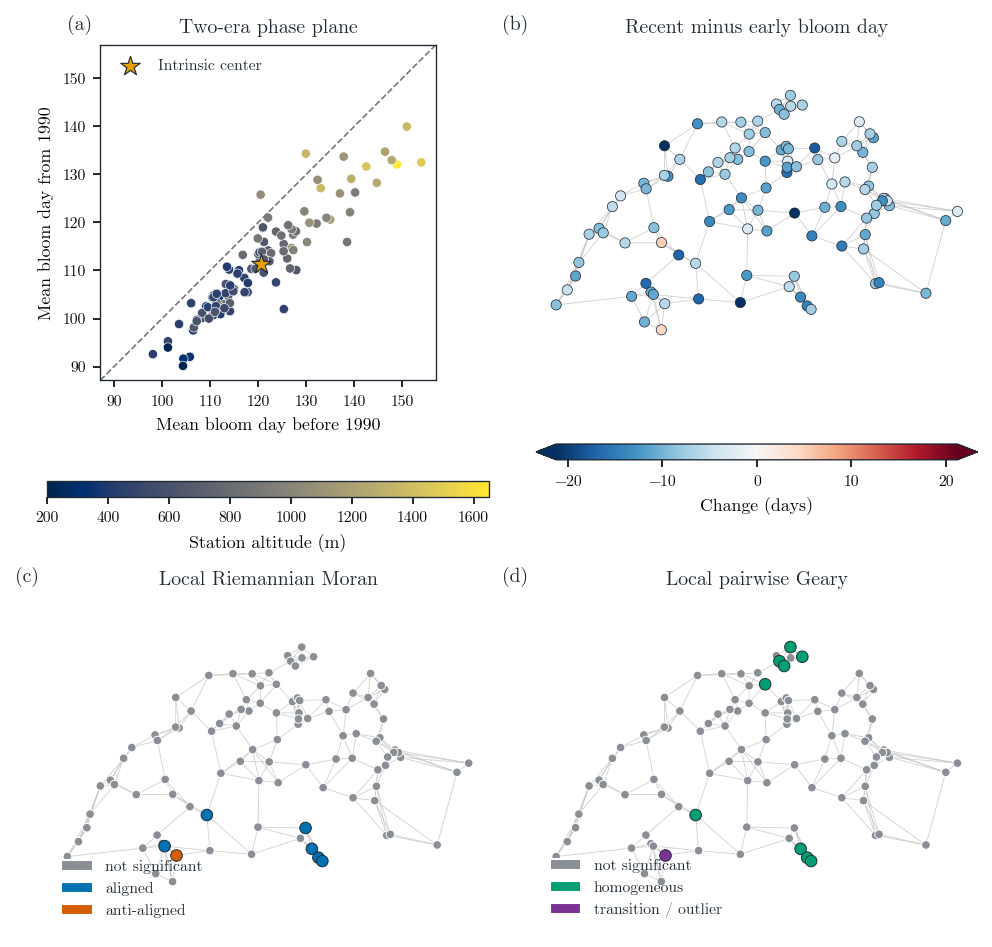

In [3]:
display_coordinates = local[["map_x", "map_y"]].to_numpy(float)
mean_days = mean_phase * 365.25 / ac.TAU
altitude_norm = Normalize(vmin=float(local["alt_m"].min()), vmax=float(local["alt_m"].max()))
shifts = local["recent_minus_early_days"].to_numpy(float)
shift_limit = float(np.nanpercentile(np.abs(shifts), 98))
shift_norm = TwoSlopeNorm(vmin=-shift_limit, vcenter=0.0, vmax=shift_limit)

fig, axes = plt.subplots(2, 2, figsize=(ac.TEXT_WIDTH_IN, 6.2), constrained_layout=True)
lower = min(local["mean_doy_early"].min(), local["mean_doy_recent"].min()) - 3
upper = max(local["mean_doy_early"].max(), local["mean_doy_recent"].max()) + 3
axes[0, 0].plot([lower, upper], [lower, upper], color="#777777", linestyle="--", linewidth=0.8)
phase_points = axes[0, 0].scatter(
    local["mean_doy_early"], local["mean_doy_recent"], c=local["alt_m"],
    cmap="cividis", norm=altitude_norm, s=20, edgecolors="white", linewidths=0.3,
)
axes[0, 0].scatter(mean_days[0], mean_days[1], marker="*", s=96, c=ac.GOLD,
                   edgecolors=ac.INK, linewidths=0.55, label="Intrinsic center")
axes[0, 0].set(title="Two-era phase plane", xlabel="Mean bloom day before 1990",
               ylabel="Mean bloom day from 1990", xlim=(lower, upper), ylim=(lower, upper))
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].legend(loc="upper left")
colorbar = fig.colorbar(phase_points, ax=axes[0, 0], orientation="horizontal",
                       fraction=0.05, pad=0.14, aspect=28)
colorbar.set_label("Station altitude (m)")

ac.draw_graph(axes[0, 1], display_coordinates, W)
shift_points = axes[0, 1].scatter(
    local["map_x"], local["map_y"], c=shifts, cmap="RdBu_r", norm=shift_norm,
    s=24, edgecolors=ac.INK, linewidths=0.35, zorder=3,
)
axes[0, 1].set_title("Recent minus early bloom day")
colorbar = fig.colorbar(shift_points, ax=axes[0, 1], orientation="horizontal",
                       fraction=0.05, pad=0.03, aspect=28, extend="both")
colorbar.set_label("Change (days)")
ac.map_axis(axes[0, 1])

for ax, column, palette, title in [
    (axes[1, 0], "moran_class", ac.MORAN_COLORS, "Local Riemannian Moran"),
    (axes[1, 1], "geary_class", ac.GEARY_COLORS, "Local pairwise Geary"),
]:
    ac.draw_graph(ax, display_coordinates, W)
    for label, color in palette.items():
        subset = local[local[column] == label]
        significant = subset["I_significant" if column == "moran_class" else "G_significant"].to_numpy(bool)
        ax.scatter(subset["map_x"], subset["map_y"], s=np.where(significant, 31, 17),
                   c=color, edgecolors=np.where(significant, ac.INK, "white"),
                   linewidths=0.45, zorder=3)
    ax.set_title(title)
    ax.legend(handles=[Patch(facecolor=color, edgecolor="white", label=label)
                       for label, color in palette.items()], loc="lower left")
    ac.map_axis(ax)

for letter, ax in zip("abcd", axes.ravel()):
    ac.panel_label(ax, letter)
plt.show()

**Figure 1.** Panel (a) shows the two-era phase plane, with altitude in
color and the intrinsic product-circle center marked by a star. Panel
(b) maps the recent-minus-early phase difference over the station graph.
Panels (c) and (d) show the FDR-adjusted local Moran and pairwise Geary
classes.

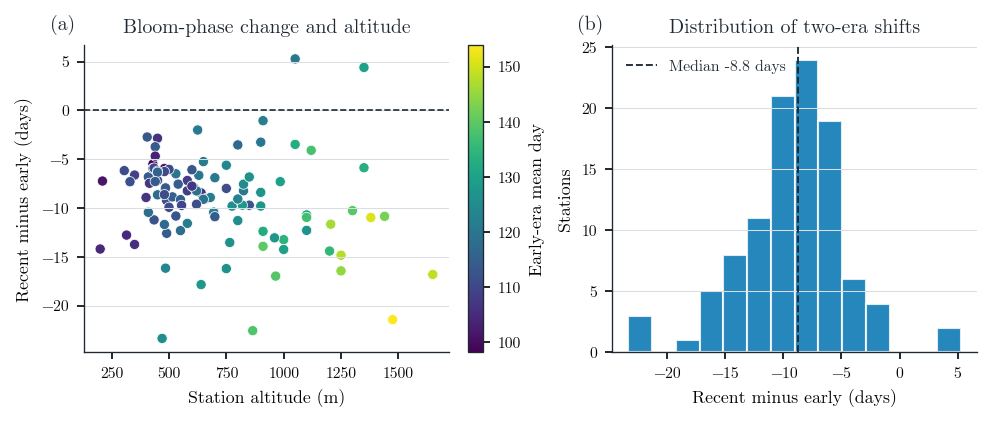

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(ac.TEXT_WIDTH_IN, 2.7), constrained_layout=True)
points = axes[0].scatter(local["alt_m"], local["recent_minus_early_days"],
                         c=local["mean_doy_early"], cmap="viridis",
                         s=24, edgecolors="white", linewidths=0.35)
axes[0].axhline(0, color=ac.INK, linestyle="--", linewidth=0.8)
axes[0].set(xlabel="Station altitude (m)", ylabel="Recent minus early (days)",
            title="Bloom-phase change and altitude")
colorbar = fig.colorbar(points, ax=axes[0])
colorbar.set_label("Early-era mean day")

axes[1].hist(local["recent_minus_early_days"], bins=14, color=ac.BLUE,
             alpha=0.85, edgecolor="white")
axes[1].axvline(np.median(local["recent_minus_early_days"]), color=ac.INK,
                linestyle="--", linewidth=0.9,
                label=f"Median {np.median(local['recent_minus_early_days']):.1f} days")
axes[1].set(xlabel="Recent minus early (days)", ylabel="Stations",
            title="Distribution of two-era shifts")
axes[1].legend()
for letter, ax in zip("ab", axes):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=ac.GRID, linewidth=0.5)
    ac.panel_label(ax, letter)
plt.show()

**Figure 2.** Additional phase diagnostics. Panel (a) relates the
two-era phase shift to station altitude. Panel (b) shows the marginal
distribution of those shifts. Negative values indicate earlier recent
bloom.

In [5]:
paper_result = paper["swiss_phenological_phases"]
comparison = pd.DataFrame([
    {"run": "Fresh notebook", **summary},
    {"run": "Archived manuscript", **paper_result},
])
display(comparison[[
    "run", "I", "C_F", "C_P", "C_T", "p_I_upper", "p_CP_lower",
    "local_moran_aligned", "local_moran_anti_aligned",
    "local_geary_homogeneous", "local_geary_transition_outlier",
]].round(4))

discoveries = local[local["I_significant"] | local["G_significant"]][
    ["location", "recent_minus_early_days", "q_local_I", "I_direction", "q_local_G", "G_direction"]
].sort_values(["q_local_I", "q_local_G", "location"])
display(discoveries.round(4))
print("Source: MeteoSwiss.")

,run,I,C_F,C_P,C_T,p_I_upper,p_CP_lower,local_moran_aligned,local_moran_anti_aligned,local_geary_homogeneous,local_geary_transition_outlier
0,Fresh notebook,0.2926,0.654,0.654,0.654,0.001,0.001,6,1,9,1
1,Archived manuscript,0.2926,0.654,0.654,0.654,0.001,0.001,6,1,9,1


,location,recent_minus_early_days,q_local_I,I_direction,q_local_G,G_direction
4,Aurigeno,-13.7325,0.0297,aligned,0.0260,homogeneous
46,Leytron,-5.9451,0.0297,anti-aligned,0.0260,transition/outlier
49,Locarno,-14.2008,0.0297,aligned,0.0260,homogeneous
92,Vira / Gambarogno,-7.2345,0.0297,aligned,0.0260,homogeneous
0,Adelboden,-5.8710,0.0297,aligned,0.0416,homogeneous
42,Les Plans-sur-Bex,-10.9615,0.0297,aligned,0.2080,homogeneous
70,Prato-Sornico,-7.9899,0.0297,aligned,0.4160,homogeneous
63,Oberehrendingen,-9.2412,0.2080,aligned,0.0260,homogeneous
68,Osterfingen,-10.4399,0.2674,aligned,0.0416,homogeneous
17,Diessenhofen,-6.8127,0.3048,aligned,0.0260,homogeneous


Source: MeteoSwiss.
